# 13. 특잇값 분해

## 모든 직사각형 행렬에 적용되는 분해

- **배울 것**: SVD의 세 행렬, reduced SVD, 저랭크 근사, 조건수와 의사역행렬.

$$
A=U\Sigma V^T=\sum_{i=1}^{r}\sigma_i\mathbf u_i\mathbf v_i^T,
\qquad \sigma_1\ge\cdots\ge\sigma_r>0
$$

- 입력 방향을 $V^T$로 바꾸고, $\Sigma$로 늘리거나 줄인 뒤, U 방향으로 표현합니다.
- 고유분해와 달리 직사각형이나 대각화 불가능한 행렬에도 적용됩니다.
- `np.linalg.svd`의 세 번째 반환값은 V가 아니라 **Vt**입니다. 실수 행렬에서는 전치, 복소수에서는 켤레전치입니다.
- $m\times n$의 reduced SVD에서 $k=\min(m,n)$이면 U는 $m\times k$, s는 길이 k, Vt는 $k\times n$입니다. 수치 랭크 r과 k는 다를 수 있습니다.

## 중요한 성분부터 더하기

$$
A_k=\sum_{i=1}^k\sigma_i\mathbf u_i\mathbf v_i^T,\qquad
\|A-A_k\|_F^2=\sum_{i>k}\sigma_i^2
$$

- 한 항은 열벡터와 행벡터의 외적이므로 랭크 1입니다. 큰 특잇값 항부터 더하면 주요 패턴이 복원됩니다.
- $A=\operatorname{diag}(3,1)$에서 첫 성분만 남기면 $A_1=\operatorname{diag}(3,0)$이고 프로베니우스 오차는 1입니다.
- 에너지 보존 비율은 $\sum_{i\le k}\sigma_i^2/\sum_i\sigma_i^2$입니다. 특잇값 자체의 비율과 다릅니다.
- 중심화한 데이터에 적용할 때 제곱 특잇값 비율이 PCA의 설명분산 비율과 연결됩니다.

## 작은 특잇값을 역수로 만들 때의 주의점

$$
A^+=V\Sigma^+U^T,\qquad
\sigma_i^+=\begin{cases}1/\sigma_i&\sigma_i>\tau\\0&\text{그 외}\end{cases}
$$

- 허용오차보다 작은 특잇값은 역수를 취하지 않습니다. 그렇지 않으면 반올림 오차가 크게 증폭됩니다.
- 양의 준정부호 대칭행렬은 고윳값과 특잇값이 같습니다. 일반 실수 대칭행렬에서는 특잇값이 고윳값의 절댓값입니다.
- 완전랭크 행렬의 2-조건수는 최대·최소 특잇값 비율입니다. `diag(42,1)`의 조건수는 42입니다.
- **주의**: 부호나 중복 특잇값 부분공간의 기저는 유일하지 않습니다. U의 원소가 같은지만 보지 말고 재구성과 직교성을 검사하세요.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch13'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260938)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260938)

재현용 난수 시드: 20260938


### 코드 13-01

- 원본: `original_py/LA4DS_ch13.py` 1–7행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 특잇값 분해

### 코드 13-02

- 원본: `original_py/LA4DS_ch13.py` 11–38행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<ipython-input-3-41758cb879c4>:15: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_title('$\mathbf{A}$\nThe matrix')
<ipython-input-3-41758cb879c4>:18: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title('$\mathbf{U}$\n(left singular vects)')
<ipython-input-3-41758cb879c4>:21: SyntaxWarning: invalid escape sequence '\m'
  axs[2].set_title('$\mathbf{\Sigma}$\n(singular vals)')
<ipython-input-3-41758cb879c4>:24: SyntaxWarning: invalid escape sequence '\m'
  axs[3].set_title('$\mathbf{V}$\n(right singular vects)')


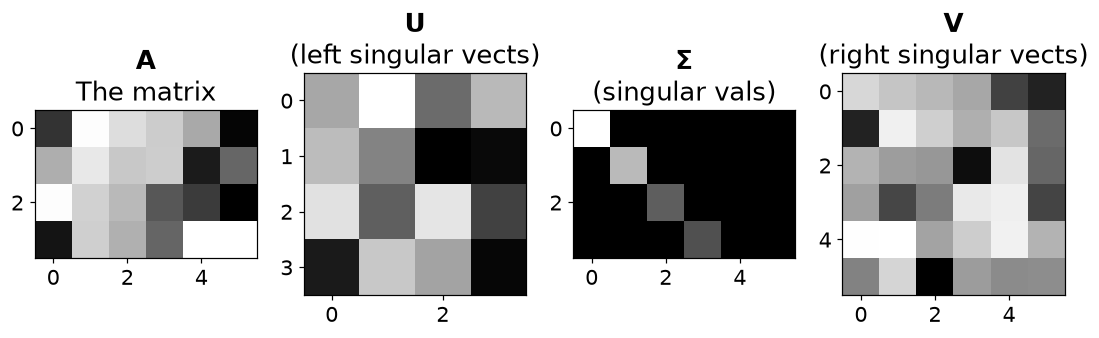

In [3]:
A = np.random.randn(4,6)

# its SVD
U,s,Vt = np.linalg.svd(A)

# create Sigma from sigma's
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)


# show the matrices
_,axs = plt.subplots(1,4,figsize=(10,6))

axs[0].imshow(A,cmap='gray',aspect='equal')
axs[0].set_title('$\mathbf{A}$\nThe matrix')

axs[1].imshow(U,cmap='gray',aspect='equal')
axs[1].set_title('$\mathbf{U}$\n(left singular vects)')

axs[2].imshow(S,cmap='gray',aspect='equal')
axs[2].set_title('$\mathbf{\Sigma}$\n(singular vals)')

axs[3].imshow(Vt,cmap='gray',aspect='equal')
axs[3].set_title('$\mathbf{V}$\n(right singular vects)')

plt.tight_layout()
plt.savefig(ASSET / 'Figure_13_02.png',dpi=140)
plt.show()

### 대칭행렬과 SVD

### 코드 13-03

- 원본: `original_py/LA4DS_ch13.py` 42–51행.
- **보완**: 실수 대칭행렬의 고유분해에는 전용 eigh를 사용합니다.

In [4]:
A = np.random.randn(5,5)
A = A.T@A

# extract eigenvalues and singular values
eigvals = np.linalg.eigh(A)[0]
sinvals = np.linalg.svd(A)[1]

# they're the same!
print(np.sort(eigvals))
print(np.sort(sinvals))

[ 0.35031   1.71535   5.479531 12.067078 17.457378]
[ 0.35031   1.71535   5.479531 12.067078 17.457378]


## 연습문제 1 · 고유분해와 SVD 비교

- **목표**: 양의 준정부호 대칭행렬에서 두 분해의 관계를 확인합니다.
- **풀이 순서**: AtA를 만들고 고윳값·특잇값을 정렬해 비교합니다. 고유벡터와 특이벡터는 합과 차이를 모두 확인합니다.
- **결과 해석**: 값은 일치하고 벡터는 부호 차이가 있을 수 있습니다. A+At로 바꾸면 음의 고윳값이 가능해 특잇값과 직접 같은 값이 아닐 수 있습니다.

### 코드 13-04

- 원본: `original_py/LA4DS_ch13.py` 55–85행.
- **보완**: 실수 대칭행렬의 고유분해에는 전용 eigh를 사용합니다.

In [5]:
# create a symmetric matrix
A = np.random.randn(5,5)
A = A.T@A
# A = A+A.T # uncomment this line to repeat for A+A'

# eigendecomposition
evals,evecs = np.linalg.eigh(A)

# sorting them helps the comparison!
sidx  = np.argsort(evals)[::-1]
evals = evals[sidx]
evecs = evecs[:,sidx]



# SVD
U,s,Vt = np.linalg.svd(A)

# compare the eigenvalues and singular values
print('Eigenvalues and singular values:')
print(np.vstack((evals,s)).T)

# now compare the left and right singular vectors
print(f'\nLeft-Right singular vectors (should be zeros)')
print(np.round(U-Vt.T,10)) # remember to compare V not V^T!

# then compare singular vectors with eigenvectors
print(f'\nSingular vectors - eigenvectors (should be zeros)')
print(np.round(U-evecs,10)) # subtract and 
print(' ')                  
print(np.round(U+evecs,10)) # add for sign indeterminancy

Eigenvalues and singular values:
[[10.444567 10.444567]
 [ 5.715894  5.715894]
 [ 2.081547  2.081547]
 [ 0.770486  0.770486]
 [ 0.109096  0.109096]]

Left-Right singular vectors (should be zeros)
[[ 0. -0.  0. -0.  0.]
 [-0. -0.  0.  0.  0.]
 [ 0.  0.  0. -0. -0.]
 [ 0.  0. -0. -0.  0.]
 [ 0. -0.  0.  0. -0.]]

Singular vectors - eigenvectors (should be zeros)
[[-0.164274 -0.        0.017107  0.        1.160307]
 [-0.707409 -0.       -1.510106  0.        0.123199]
 [-0.13377  -0.       -0.324267  0.        1.443616]
 [-1.465902 -0.       -0.219135 -0.       -0.630299]
 [-1.142727 -0.        1.251446  0.        0.396493]]
 
[[ 0.        0.436438 -0.        1.560747 -0.      ]
 [-0.       -1.086356 -0.        0.154287 -0.      ]
 [-0.        0.526738  0.       -1.231047  0.      ]
 [-0.        1.185587 -0.       -0.014836  0.      ]
 [ 0.       -0.972772  0.       -0.156737 -0.      ]]


## 연습문제 2 · reduced SVD 크기

- **목표**: 불필요한 완전기저를 저장하지 않는 방법을 확인합니다.
- **풀이 순서**: 10×4 행렬에 full_matrices=False를 적용하고 세 반환값의 shape를 봅니다.
- **결과 해석**: U는 10×4, s는 길이 4, Vt는 4×4입니다. 이것은 수치 랭크를 찾아 0 특잇값을 제거하는 절단 SVD와 다릅니다.

### 코드 13-05

- 원본: `original_py/LA4DS_ch13.py` 90–101행.

In [6]:
# sizes (try tall and wide)
m = 10
n = 4

# random matrix and its economy (aka reduced) SVD
A = np.random.randn(m,n)
U,s,Vt = np.linalg.svd(A,full_matrices=False)

# print sizes
print(f'Size of A:  {A.shape}')
print(f'Size of U:  {U.shape}')
print(f"Size of V': {Vt.shape}")

Size of A:  (10, 4)
Size of U:  (10, 4)
Size of V': (4, 4)


## 연습문제 3 · 직교성과 길이 보존

- **목표**: SVD의 U가 길이를 보존하는지 확인합니다.
- **풀이 순서**: $(Uw)^T(Uw)=w^TU^TUw=w^Tw$를 전개하고 난수 벡터로 검증합니다.
- **결과 해석**: 두 노름이 같습니다. 원본 주석의 여분 U 전치는 단순 오타이며 정확한 전개는 본 설명과 같습니다.

### 코드 13-06

- 원본: `original_py/LA4DS_ch13.py` 105–115행.

In [7]:
# The proof that |Uw|=|w| comes from expanding the vector magnitude to the dot product:
# |Uw|^2 = (Uw)'(Uw) = w'U'U'w = w'Iw = w'w = |w|^2


# empirical demonstration:
U,s,Vt = np.linalg.svd(np.random.randn(5,5))
w = np.random.randn(5,1)

# print out the norms
print( np.linalg.norm(U@w) )
print( np.linalg.norm(  w) )

2.651391952598285
2.6513919525982854


## 연습문제 4 · 조건수 42인 행렬 만들기

- **목표**: 특잇값을 설계하면 민감도를 조절할 수 있음을 봅니다.
- **풀이 순서**: 직교 U,Vt를 만들고 최대 42·최소 1인 특잇값을 대각에 넣어 곱합니다.
- **결과 해석**: 결과 A의 2-조건수는 약 42입니다. 직교행렬의 회전은 특잇값을 바꾸지 않습니다.

### 코드 13-07

- 원본: `original_py/LA4DS_ch13.py` 119–157행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:31: SyntaxWarning: invalid escape sequence '\S'
<ipython-input-8-4b050e4d8c8d>:31: SyntaxWarning: invalid escape sequence '\S'
  axs[2].set_title(f'$\Sigma$ (cond={np.linalg.cond(S):.3f})')


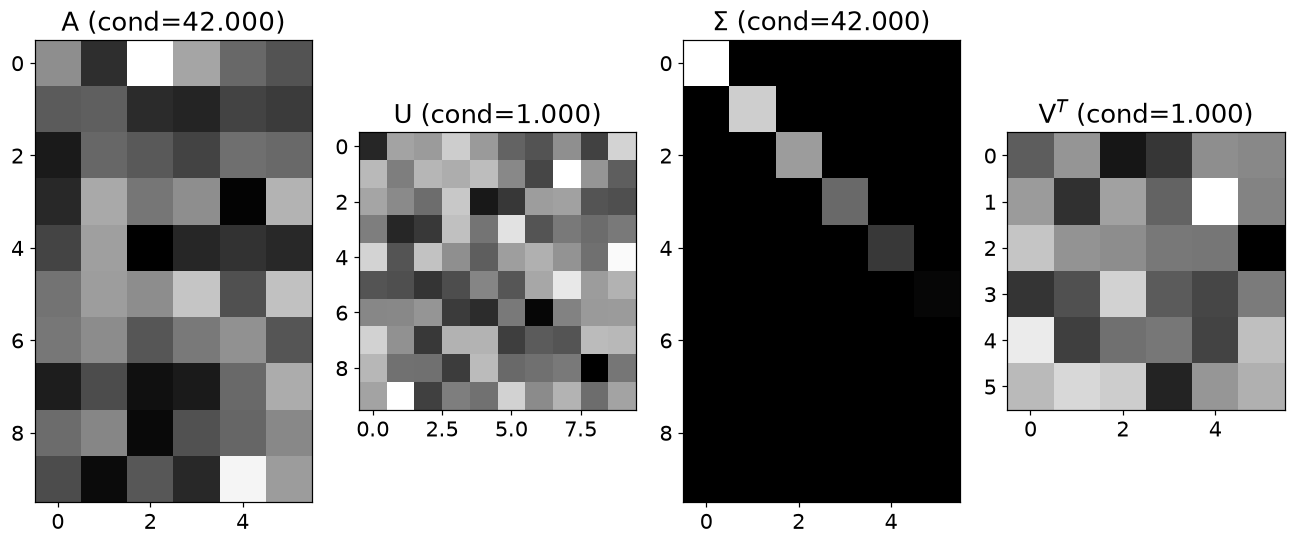

In [8]:
# create a tall matrix with specified condition number
m = 10
n = 6

condnum = 42

# create U and V from random numbers
U,_  = np.linalg.qr( np.random.randn(m,m) )
Vt,_ = np.linalg.qr( np.random.randn(n,n) )

# create singular values vector
s = np.linspace(condnum,1,np.min((m,n)))

# convert into a matrix
S = np.zeros((m,n))
np.fill_diagonal(S,s)

# create matrix
A = U@S@Vt

# and show in a plot
_,axs = plt.subplots(1,4,figsize=(12,6))

axs[0].imshow(A, aspect='equal', cmap='gray')
axs[0].set_title(f'A (cond={np.linalg.cond(A):.3f})')

axs[1].imshow(U, aspect='equal', cmap='gray')
axs[1].set_title(f'U (cond={np.linalg.cond(U):.3f})')

axs[2].imshow(S, aspect='equal', cmap='gray')
axs[2].set_title(f'$\Sigma$ (cond={np.linalg.cond(S):.3f})')

axs[3].imshow(Vt, aspect='equal', cmap='gray')
axs[3].set_title(f'V$^T$ (cond={np.linalg.cond(Vt):.3f})')


plt.tight_layout()
plt.savefig(ASSET / 'Figure_13_04.png',dpi=140)
plt.show()

## 연습문제 5 · 랭크 1 층으로 재구성

- **목표**: SVD 항이 이미지 패턴을 어떻게 더하는지 봅니다.
- **풀이 순서**: 평활화한 난수행렬을 SVD하고 첫 네 외적 층과 누적합을 그립니다. 제곱 특잇값 비율도 확인합니다.
- **결과 해석**: 큰 구조가 먼저 복원됩니다. 원본의 s/sum(s)는 에너지 비율이 아니므로 s²/sum(s²)로 수정했습니다.

### 코드 13-08

- 원본: `original_py/LA4DS_ch13.py` 161–212행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: SVD의 에너지 비율은 특잇값의 제곱으로 계산합니다.
- **보완**: 중심화하지 않은 행렬이므로 분산 대신 제곱 에너지 비율로 표기했습니다.

<>:34: SyntaxWarning: invalid escape sequence '\S'
<ipython-input-9-8aaff1eb5278>:34: SyntaxWarning: invalid escape sequence '\S'
  axs[2].set_title('$\Sigma$')


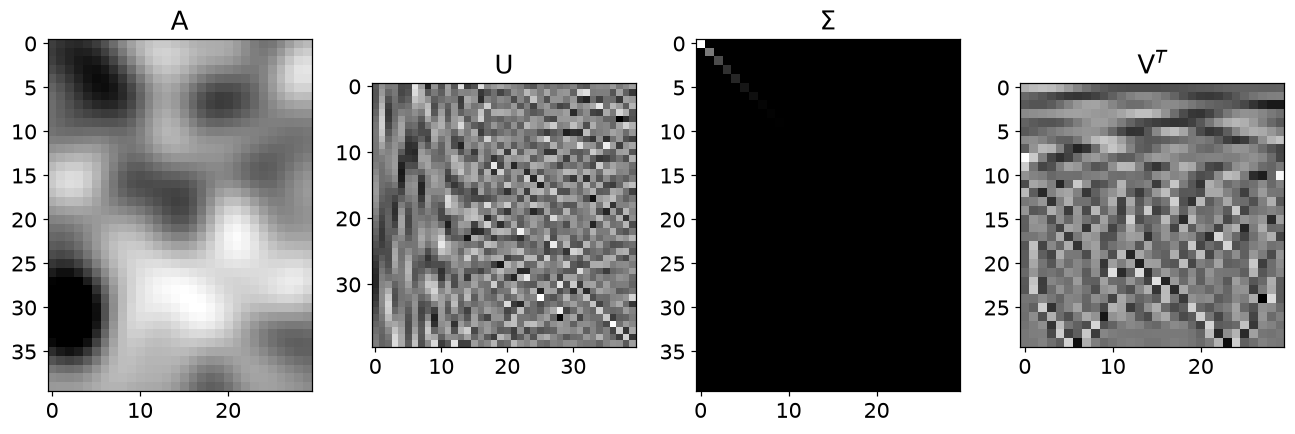

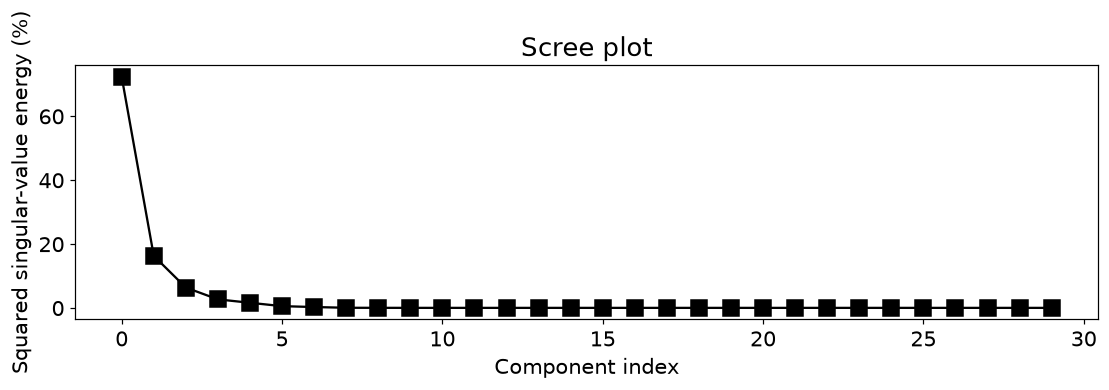

In [9]:
# create the matrix
m = 40
n = 30

# define a 2D Gaussian for smoothing
k = int((m+n)/4)
X,Y = np.meshgrid(np.linspace(-3,3,k),np.linspace(-3,3,k))
g2d = np.exp( -(X**2 + Y**2)/(k/8) )


# now for the matrix
from scipy.signal import convolve2d
A = convolve2d(np.random.randn(m,n),g2d,mode='same')


# SVD and create Sigma
U,s,Vt = np.linalg.svd(A)
S = np.zeros(np.shape(A))
np.fill_diagonal(S,s)


# visualize the matrices

# and show in a plot
_,axs = plt.subplots(1,4,figsize=(12,6))

axs[0].imshow(A, aspect='equal', cmap='gray', vmin=-10,vmax=10)
axs[0].set_title('A')

axs[1].imshow(U, aspect='equal', cmap='gray')
axs[1].set_title('U')

axs[2].imshow(S, aspect='equal', cmap='gray')
axs[2].set_title('$\Sigma$')

axs[3].imshow(Vt, aspect='equal', cmap='gray')
axs[3].set_title('V$^T$')


plt.tight_layout()
plt.savefig(ASSET / 'Figure_13_05a.png',dpi=140)
plt.show()


# and show the scree plot
plt.figure(figsize=(12,3))
plt.plot(100*s**2/np.sum(s**2),'ks-',markersize=10)
plt.xlabel('Component index')
plt.ylabel('Squared singular-value energy (%)')
plt.title('Scree plot')
plt.savefig(ASSET / 'Figure_13_05b.png',dpi=140)
plt.show()

### 코드 13-09

- 원본: `original_py/LA4DS_ch13.py` 214–242행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

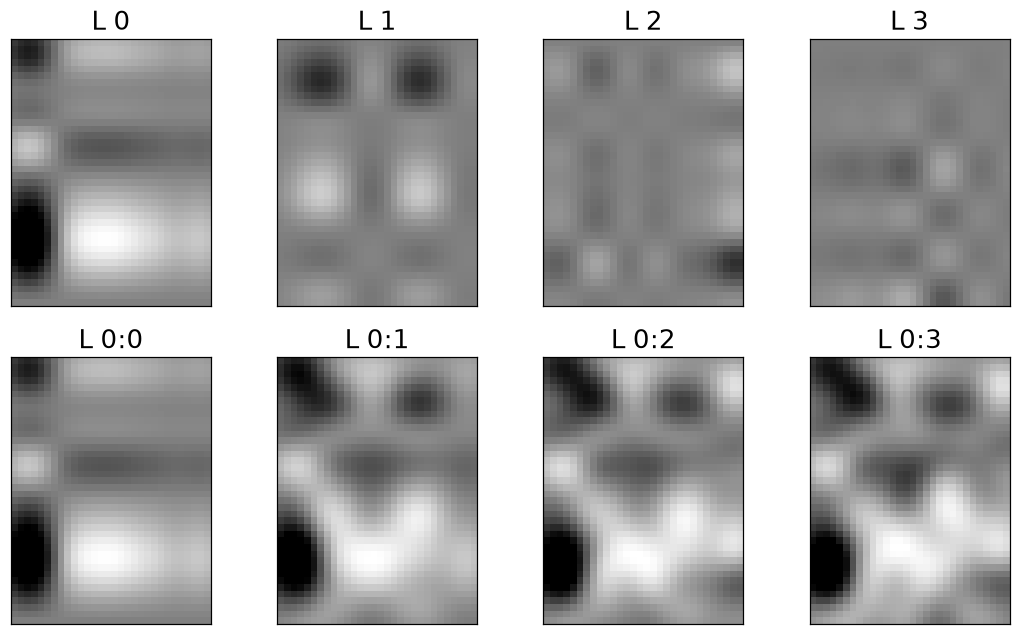

In [10]:
## now show the first N "layers" separately and summed

numLayers = 4
rank1mats = np.zeros((numLayers,m,n))


# setup the figure
_,axs = plt.subplots(2,numLayers,figsize=(10,6))

# the loop
for i in range(numLayers):
    
    # create this layer
    rank1mats[i,:,:] = np.outer(U[:,i],Vt[i,:])*S[i,i]
    
    # show this layer
    axs[0,i].imshow(rank1mats[i,:,:],cmap='gray', vmin=-10,vmax=10)
    axs[0,i].set_title(f'L {i}')
    axs[0,i].set_xticks([]), axs[0,i].set_yticks([])

    # show the cumulative sum of layers
    axs[1,i].imshow(np.sum(rank1mats[:i+1,:,:],axis=0),cmap='gray', vmin=-10,vmax=10)
    axs[1,i].set_title(f'L 0:{i}')
    axs[1,i].set_xticks([]), axs[1,i].set_yticks([])


plt.tight_layout()
plt.savefig(ASSET / 'Figure_13_05c.png',dpi=140)
plt.show()

## 연습문제 6 · SVD로 pinv 구현

- **목표**: 0에 가까운 특잇값을 역수로 만들지 않는 이유를 이해합니다.
- **풀이 순서**: 랭크 3인 5×5 행렬을 분해하고 허용오차보다 큰 s만 역수로 바꿔 VΣ+Ut를 구성합니다.
- **결과 해석**: NumPy pinv와 차이는 0 근처입니다. 허용오차 선택에 따라 어떤 방향을 버릴지 달라질 수 있습니다.

### 코드 13-10

- 원본: `original_py/LA4DS_ch13.py` 246–269행.

In [11]:
# singular matrix
A = np.random.randn(5,3) @ np.random.randn(3,5)

# its SVD
U,s,Vt = np.linalg.svd(A)

# define a threshold (tolerance) for "zero-valued" singular values
# I thought of using eps scaled by the size of A. Numpy fixed this to 10^-15, 
# which means it is not adapted to different computer precisions.
tol = np.finfo(float).eps * np.max(A.shape)

# invert the supra-threshhold sigma's
sInv = np.zeros_like(s)
sInv[s>tol] = 1/s[s>tol]

# reconstruct
S = np.zeros_like(A)
np.fill_diagonal(S,sInv)
Apinv = Vt.T @ S @ U.T

# compare to pinv()
ApinvNp = np.linalg.pinv(A)

print(np.round( ApinvNp - Apinv ,5))

[[ 0. -0. -0.  0. -0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -0.]
 [-0.  0.  0.  0.  0.]]


### 코드 13-11

- 원본: `original_py/LA4DS_ch13.py` 271–272행.
- **보완**: IPython 소스 보기 명령을 함수 시그니처와 설명 출력으로 변환했습니다. 전체 소스는 inspect.getsource로 확인할 수 있습니다.

In [12]:
# check the source code for pinv
import inspect
print(inspect.signature(np.linalg.pinv))
print(inspect.getdoc(np.linalg.pinv).split("\n\n")[0])

(a, rcond=None, hermitian=False, *, rtol=<no value>)
Compute the (Moore-Penrose) pseudo-inverse of a matrix.


## 연습문제 7 · 좌·우 역행렬과 pinv

- **목표**: full rank 직사각형에서 의사역행렬의 구체적 식을 검증합니다.
- **풀이 순서**: 6×4와 4×6 행렬에서 왼쪽·오른쪽 공식을 각각 계산해 pinv와 비교합니다.
- **결과 해석**: 차이는 반올림 오차입니다. 랭크 부족이면 Gram 역행렬 식 대신 SVD 기반 pinv가 필요합니다.

### 코드 13-12

- 원본: `original_py/LA4DS_ch13.py` 276–286행.

In [13]:
# left-inverse
A = np.random.randn(6,4)

# explicit left inverse
Linv = np.linalg.inv(A.T@A)@A.T

# pinv
Apinv = np.linalg.pinv(A)

# compare
print(np.round( Linv - Apinv ,5))

[[-0.  0.  0.  0.  0.  0.]
 [-0. -0. -0.  0. -0.  0.]
 [ 0. -0. -0. -0. -0. -0.]
 [-0.  0.  0. -0.  0.  0.]]


### 코드 13-13

- 원본: `original_py/LA4DS_ch13.py` 288–298행.

In [14]:
# right-inverse
A = np.random.randn(4,6)

# explicit right inverse
Rinv = A.T@np.linalg.inv(A@A.T)

# pinv
Apinv = np.linalg.pinv(A)

# compare
print(np.round( Rinv - Apinv ,5))

[[ 0.  0.  0.  0.]
 [-0. -0.  0. -0.]
 [-0. -0.  0. -0.]
 [ 0.  0. -0. -0.]
 [-0. -0.  0.  0.]
 [ 0.  0. -0. -0.]]


## 연습문제 8 · 고유방정식에 벡터 의사역행렬 곱하기

- **목표**: 벡터를 ‘나눈다’는 말 대신 곱의 방향과 shape를 확인합니다.
- **풀이 순서**: Mv=λv에 v+를 왼쪽 또는 오른쪽에 곱해 비교합니다. 먼저 v+v=1을 확인합니다.
- **결과 해석**: 왼쪽 곱은 스칼라 λ, 오른쪽 곱은 λvv+인 행렬입니다. vv+는 투영행렬이므로 항등행렬이라고 소거하면 안 됩니다.

### 코드 13-14

- 원본: `original_py/LA4DS_ch13.py` 302–316행.

In [15]:
# the matrix (from chapter 11)
M = np.array([ [-1,1],
               [-1,2] ])

# its eigendecomposition
evals,evecs = np.linalg.eig(M)
l = evals[1]     # extract lambda1 for convenience
v = evecs[:,[1]] # extract v1 for convenience

LHS = M@v
RHS = l*v

# print out the two sides (as row vectors for visual convenience)
print(LHS.T)
print(RHS.T)

[[-0.57735 +0.j -1.511523+0.j]]
[[-0.57735 +0.j -1.511523+0.j]]


### 코드 13-15

- 원본: `original_py/LA4DS_ch13.py` 318–322행.

In [16]:
# pinv(v)
vPinv = np.linalg.pinv(v)

# check
vPinv@v

Out[16]: array([[1.+0.j]])


### 코드 13-16

- 원본: `original_py/LA4DS_ch13.py` 324–330행.

In [17]:
# first equation
LHS = vPinv @ M @ v
RHS = l * vPinv @ v

# these results are scalars (quadratic form)
print(LHS)
print(RHS)

[[1.618034+0.j]]
[[1.618034+0.j]]


### 코드 13-17

- 원본: `original_py/LA4DS_ch13.py` 332–338행.

In [18]:
# second equation
LHS = M @ v @ vPinv
RHS = l * v @ vPinv

# these results are matrices
print(LHS), print(' ')
print(RHS)

[[0.206011+0.j 0.539345+0.j]
 [0.539345+0.j 1.412023+0.j]]
 
[[0.206011+0.j 0.539345+0.j]
 [0.539345+0.j 1.412023+0.j]]


## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [19]:
_A=np.diag([3.,1.]); _U,_s,_Vt=np.linalg.svd(_A,full_matrices=False)
_Ak=(_U[:,:1]*_s[:1])@_Vt[:1]
_error=np.linalg.norm(_A-_Ak,'fro')
print('rank 1 재구성:\n',_Ak)
print('오차:',_error,'보존 에너지:',_s[0]**2/np.sum(_s**2))
assert np.allclose(_error,1) and np.allclose(_error**2,np.sum(_s[1:]**2))


rank 1 재구성:
 [[3. 0.]
 [0. 0.]]
오차: 1.0 보존 에너지: 0.9
